In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
label = LabelEncoder()
df['Gender'] = label.fit_transform(df['Gender'])

In [4]:
model = KMeans(n_clusters=2,random_state=42)
result = model.fit_predict(df)
values = model.fit_transform(df)

In [5]:
df['result'] = result

In [6]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),result
0,1,1,19,15,39,0
1,2,1,21,15,81,0
2,3,0,20,16,6,0
3,4,0,23,16,77,0
4,5,0,31,17,40,0
...,...,...,...,...,...,...
195,196,0,35,120,79,1
196,197,0,45,126,28,1
197,198,1,32,126,74,1
198,199,1,32,137,18,1


In [7]:
c1 = df[df['result']==0]
c2 = df[df['result']==1]

In [8]:
model.cluster_centers_

array([[ 50.        ,   0.4040404 ,  39.94949495,  39.34343434,
         49.93939394],
       [150.        ,   0.47524752,  37.77227723,  81.35643564,
         50.45544554]])

In [9]:
res = []
for i in range(1,6):
    model = KMeans(n_clusters=i)
    model.fit_predict(df)
    res.append(model.inertia_)

In [10]:
res

[975562.0549999999,
 387065.71377137717,
 272141.951409596,
 195416.95613567223,
 187284.0343372169]

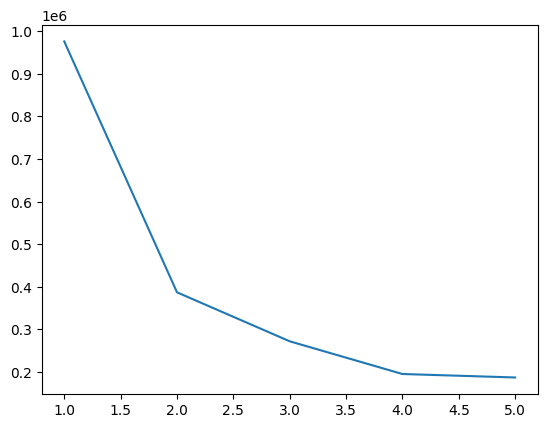

In [11]:
import matplotlib.pyplot as plt
plt.plot(range(1,6),res)

<Axes: >

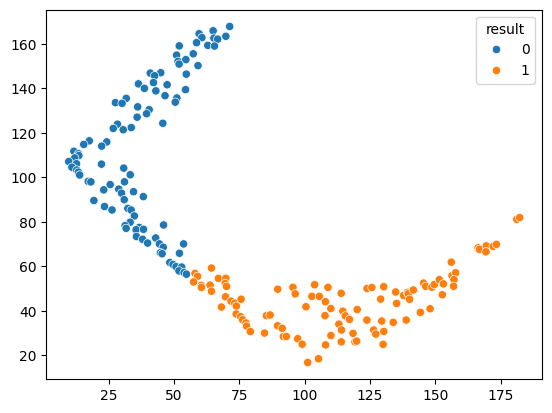

In [12]:
import seaborn as sns
sns.scatterplot(df,x = values[:,0],y = values[:,1],hue='result')

In [13]:
main_pipe = Pipeline(
    steps=[
        ('scaler',RobustScaler()),
        ('pca',PCA(n_components=2)),
        ('model',KMeans(n_clusters=2,random_state=42))
    ]
)
result = main_pipe.fit_predict(df)

NameError: name 'Pipeline' is not defined

In [ ]:
values = main_pipe.fit_transform(df)

array([[109.09067805, 182.40221701,  39.66932994],
       [111.38817411, 183.57314124,  48.05188453],
       [115.06391969, 185.09769584,  56.48458371],
       [107.84966706, 180.58697906,  43.2806321 ],
       [102.54996025, 177.15632331,  31.39045485],
       [105.67629943, 178.31246024,  41.43353358],
       [108.91966924, 180.06994868,  51.4431088 ],
       [109.18398341, 179.5550332 ,  53.2499519 ],
       [109.85458369, 180.84559048,  59.43063183],
       [ 99.13506923, 172.89484548,  33.38228646],
       [104.53654247, 177.02636379,  52.07875499],
       [106.12211267, 176.46832229,  54.0490063 ],
       [100.44170747, 173.30263722,  45.64258868],
       [ 97.4762592 , 169.9096073 ,  36.15472216],
       [ 98.60178116, 170.55078062,  41.39929516],
       [ 96.7686437 , 168.60224148,  37.57702472],
       [ 90.43977831, 164.91141457,  22.47475815],
       [ 92.11781331, 164.84059486,  28.42707091],
       [ 89.1485624 , 163.72594913,  29.26532105],
       [ 97.79312014, 167.61022

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(df,x = values[:,0],y = values[:,1],hue=result)
plt.show()